# Perception Question 2 — A Crossing with Conflicting Evidence

The aim of this task is to recommend one of three actions at each frame:

- GO
- SLOW
- STOP

The decision uses:

- red light vision score
- person vision score
- V2X traffic-light state
- V2X message timestamp
- vehicle speed
- distance to the stop line

I first build a simple baseline rule. I then revise it to account for stale V2X messages and conflicting evidence.

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
evidence = pd.read_csv("data/city/crossing_evidence.csv")

print("Number of rows:", len(evidence))

evidence.head()

Number of rows: 72


,episode,frame,time_s,distance_to_line_m,speed_mps,red_score,person_score,v2x_light,v2x_sample_time_s
0,clear_green,0,0.0,2.75,0.8,0.010,0.010,green,0.0
1,clear_green,1,0.1,2.67,0.8,0.010,0.113,green,0.1
2,clear_green,2,0.2,2.59,0.8,0.028,0.010,green,0.2
3,clear_green,3,0.3,2.51,0.8,0.010,0.153,green,0.3
4,clear_green,4,0.4,2.43,0.8,0.040,0.456,green,0.4


In [3]:
print(evidence["episode"].value_counts())

episode
clear_green        24
late_red           24
person_crossing    24
Name: count, dtype: int64


In [4]:
for episode in evidence["episode"].unique():

    print()
    print(episode)

    display(
        evidence[evidence["episode"] == episode][
            [
                "frame",
                "time_s",
                "speed_mps",
                "distance_to_line_m",
                "red_score",
                "person_score",
                "v2x_light",
                "v2x_sample_time_s"
            ]
        ].head()
    )


clear_green


,frame,time_s,speed_mps,distance_to_line_m,red_score,person_score,v2x_light,v2x_sample_time_s
0,0,0.0,0.8,2.75,0.010,0.010,green,0.0
1,1,0.1,0.8,2.67,0.010,0.113,green,0.1
2,2,0.2,0.8,2.59,0.028,0.010,green,0.2
3,3,0.3,0.8,2.51,0.010,0.153,green,0.3
4,4,0.4,0.8,2.43,0.040,0.456,green,0.4



late_red


,frame,time_s,speed_mps,distance_to_line_m,red_score,person_score,v2x_light,v2x_sample_time_s
24,0,0.0,0.8,2.75,0.090,0.146,green,0.0
25,1,0.1,0.8,2.67,0.010,0.541,green,0.1
26,2,0.2,0.8,2.59,0.010,0.010,green,0.2
27,3,0.3,0.8,2.51,0.017,0.335,green,0.3
28,4,0.4,0.8,2.43,0.108,0.078,green,0.4



person_crossing


,frame,time_s,speed_mps,distance_to_line_m,red_score,person_score,v2x_light,v2x_sample_time_s
48,0,0.0,0.8,2.75,0.010,0.187,green,0.0
49,1,0.1,0.8,2.67,0.010,0.010,green,0.1
50,2,0.2,0.8,2.59,0.224,0.010,green,0.2
51,3,0.3,0.8,2.51,0.010,0.010,green,0.3
52,4,0.4,0.8,2.43,0.010,0.010,green,0.4


## A. What information does the car have?

The camera-based evidence is uncertain. A high `red_score` supports the presence of a red traffic light, while a high `person_score` supports the presence of a visible person.

The V2X message gives another estimate of the traffic-light state, but it may be stale because it was sampled at an earlier time.

The vehicle also knows its current speed and distance from the stop line. These are important because even a correct STOP decision is unsafe if it is made too late.

The reference file is not available to the running decision system and will only be used later for evaluation.

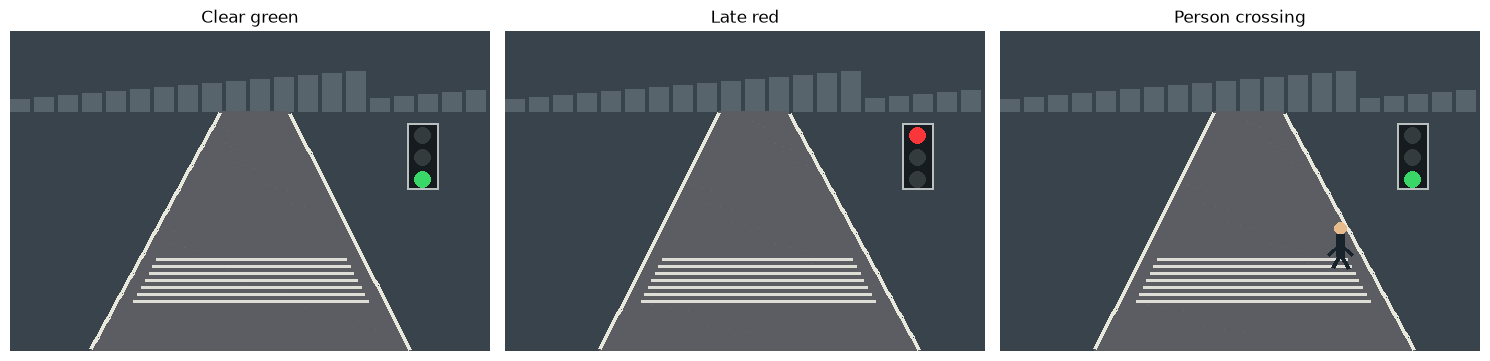

In [5]:
sample_paths = [
    "data/city/crossing/clear_green/000.png",
    "data/city/crossing/late_red/012.png",
    "data/city/crossing/person_crossing/012.png"
]

titles = [
    "Clear green",
    "Late red",
    "Person crossing"
]

plt.figure(figsize=(15, 5))

for i in range(3):

    img = cv2.imread(sample_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## B. Baseline decision rule

I first use a simple threshold-based rule.

The three actions mean:

- **GO:** current evidence does not indicate an immediate conflict.
- **SLOW:** some evidence is suspicious, but it is not strong enough to justify an immediate stop.
- **STOP:** strong evidence indicates a red light, a person-related hazard, or a red V2X signal.

For this baseline, I intentionally treat the V2X state as if it were current. I do not yet check the age of the message. This gives a simple starting point whose failure can be studied later.

The thresholds are:

- `red_score >= 0.75` → strong red-light evidence
- `person_score >= 0.80` → strong person evidence
- `red_score >= 0.40` or `person_score >= 0.60` → uncertain evidence, so SLOW

In [6]:
def baseline_decision(row):

    red = row["red_score"]
    person = row["person_score"]
    v2x = row["v2x_light"]

    # strong red-light evidence
    if red >= 0.75:
        return "STOP", "high red vision score"

    # strong person evidence
    if person >= 0.80:
        return "STOP", "high person vision score"

    # baseline trusts V2X directly
    if v2x == "red":
        return "STOP", "V2X reports red"

    # uncertain visual evidence
    if red >= 0.40:
        return "SLOW", "moderate red vision score"

    if person >= 0.60:
        return "SLOW", "moderate person vision score"

    return "GO", "no strong hazard evidence"

In [7]:
baseline_actions = []
baseline_reasons = []

for i in range(len(evidence)):

    action, reason = baseline_decision(evidence.iloc[i])

    baseline_actions.append(action)
    baseline_reasons.append(reason)


baseline_df = evidence.copy()

baseline_df["baseline_action"] = baseline_actions
baseline_df["baseline_reason"] = baseline_reasons

baseline_df.head()

,episode,frame,time_s,distance_to_line_m,speed_mps,red_score,person_score,v2x_light,v2x_sample_time_s,baseline_action,baseline_reason
0,clear_green,0,0.0,2.75,0.8,0.010,0.010,green,0.0,GO,no strong hazard evidence
1,clear_green,1,0.1,2.67,0.8,0.010,0.113,green,0.1,GO,no strong hazard evidence
2,clear_green,2,0.2,2.59,0.8,0.028,0.010,green,0.2,GO,no strong hazard evidence
3,clear_green,3,0.3,2.51,0.8,0.010,0.153,green,0.3,GO,no strong hazard evidence
4,clear_green,4,0.4,2.43,0.8,0.040,0.456,green,0.4,GO,no strong hazard evidence


In [8]:
print(baseline_df["baseline_action"].value_counts())

baseline_action
GO      40
STOP    27
SLOW     5
Name: count, dtype: int64


In [9]:
for episode in baseline_df["episode"].unique():

    print()
    print("Episode:", episode)

    display(
        baseline_df[
            baseline_df["episode"] == episode
        ][
            [
                "frame",
                "time_s",
                "red_score",
                "person_score",
                "v2x_light",
                "baseline_action",
                "baseline_reason"
            ]
        ]
    )


Episode: clear_green


,frame,time_s,red_score,person_score,v2x_light,baseline_action,baseline_reason
0,0,0.0,0.010,0.010,green,GO,no strong hazard evidence
1,1,0.1,0.010,0.113,green,GO,no strong hazard evidence
2,2,0.2,0.028,0.010,green,GO,no strong hazard evidence
3,3,0.3,0.010,0.153,green,GO,no strong hazard evidence
4,4,0.4,0.040,0.456,green,GO,no strong hazard evidence
5,5,0.5,0.010,0.219,green,GO,no strong hazard evidence
6,6,0.6,0.365,0.770,green,SLOW,moderate person vision score
7,7,0.7,0.094,0.770,green,SLOW,moderate person vision score
8,8,0.8,0.010,0.185,green,GO,no strong hazard evidence
9,9,0.9,0.160,0.514,green,GO,no strong hazard evidence



Episode: late_red


,frame,time_s,red_score,person_score,v2x_light,baseline_action,baseline_reason
24,0,0.0,0.090,0.146,green,GO,no strong hazard evidence
25,1,0.1,0.010,0.541,green,GO,no strong hazard evidence
26,2,0.2,0.010,0.010,green,GO,no strong hazard evidence
27,3,0.3,0.017,0.335,green,GO,no strong hazard evidence
28,4,0.4,0.108,0.078,green,GO,no strong hazard evidence
29,5,0.5,0.078,0.192,green,GO,no strong hazard evidence
30,6,0.6,0.010,0.010,green,GO,no strong hazard evidence
31,7,0.7,0.069,0.010,green,GO,no strong hazard evidence
32,8,0.8,0.010,0.018,green,GO,no strong hazard evidence
33,9,0.9,0.430,0.010,red,STOP,V2X reports red



Episode: person_crossing


,frame,time_s,red_score,person_score,v2x_light,baseline_action,baseline_reason
48,0,0.0,0.010,0.187,green,GO,no strong hazard evidence
49,1,0.1,0.010,0.010,green,GO,no strong hazard evidence
50,2,0.2,0.224,0.010,green,GO,no strong hazard evidence
51,3,0.3,0.010,0.010,green,GO,no strong hazard evidence
52,4,0.4,0.010,0.010,green,GO,no strong hazard evidence
53,5,0.5,0.142,0.010,green,GO,no strong hazard evidence
54,6,0.6,0.121,0.010,green,GO,no strong hazard evidence
55,7,0.7,0.010,0.824,green,STOP,high person vision score
56,8,0.8,0.207,0.777,green,SLOW,moderate person vision score
57,9,0.9,0.010,0.611,green,SLOW,moderate person vision score


### Baseline behaviour

The baseline is deliberately simple. It reacts independently to the strongest current cue.

This makes the rule easy to inspect, but it has two weaknesses:

1. It treats every V2X message as current even when the message may be old.
2. It decides from each frame independently, so one noisy person score can cause an early STOP or a sudden change in action.

These weaknesses motivate the revised rule.

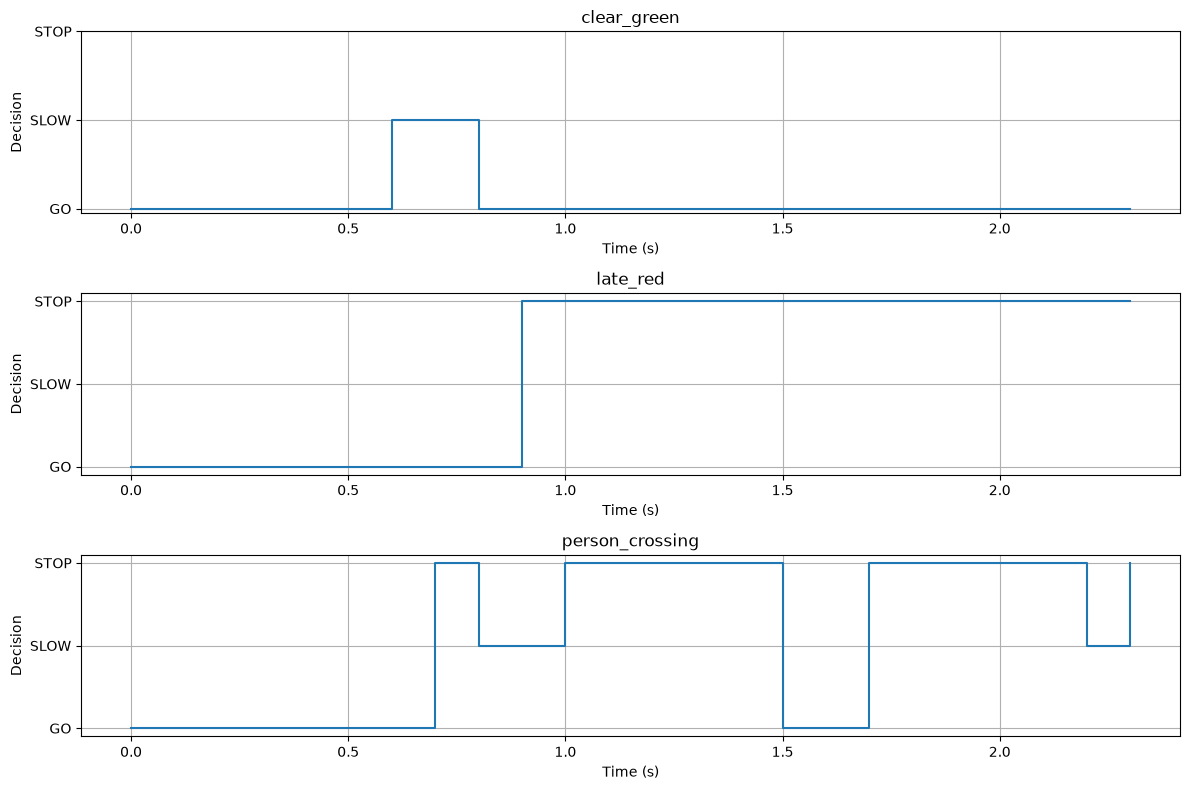

In [10]:
action_value = {
    "GO": 0,
    "SLOW": 1,
    "STOP": 2
}

baseline_df["baseline_value"] = baseline_df["baseline_action"].map(action_value)

episodes = ["clear_green", "late_red", "person_crossing"]

plt.figure(figsize=(12, 8))

for i, episode in enumerate(episodes):

    temp = baseline_df[
        baseline_df["episode"] == episode
    ]

    plt.subplot(3, 1, i + 1)

    plt.step(
        temp["time_s"],
        temp["baseline_value"],
        where="post",
        label="Baseline decision"
    )

    plt.yticks(
        [0, 1, 2],
        ["GO", "SLOW", "STOP"]
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Decision")
    plt.title(episode)

    plt.grid()

plt.tight_layout()
plt.show()

In [11]:
baseline_df["message_age"] = (
    baseline_df["time_s"]
    - baseline_df["v2x_sample_time_s"]
)

baseline_df[
    [
        "episode",
        "frame",
        "time_s",
        "v2x_light",
        "v2x_sample_time_s",
        "message_age"
    ]
].head(15)

,episode,frame,time_s,v2x_light,v2x_sample_time_s,message_age
0,clear_green,0,0.0,green,0.0,0.0
1,clear_green,1,0.1,green,0.1,0.0
2,clear_green,2,0.2,green,0.2,0.0
3,clear_green,3,0.3,green,0.3,0.0
4,clear_green,4,0.4,green,0.4,0.0
5,clear_green,5,0.5,green,0.0,0.5
6,clear_green,6,0.6,green,0.0,0.6
7,clear_green,7,0.7,green,0.7,0.0
8,clear_green,8,0.8,green,0.8,0.0
9,clear_green,9,0.9,green,0.9,0.0


In [12]:
baseline_df.groupby("episode")["message_age"].describe()

,count,mean,std,min,25%,50%,75%,max
episode,,,,,,,,
clear_green,24.0,0.145833,0.258725,0.0,0.0,0.0,0.125,0.6
late_red,24.0,0.145833,0.258725,0.0,0.0,0.0,0.125,0.6
person_crossing,24.0,0.145833,0.258725,0.0,0.0,0.0,0.125,0.6


## C. Accounting for stale and conflicting evidence

The baseline treats the V2X state as if it were always current.

I now calculate:

\[
\text{message age} = \text{current time} - \text{V2X sample time}
\]

I treat a V2X message as fresh when its age is at most 0.25 s.

The revised rule also changes the treatment of person evidence. A high person score by itself does not immediately mean that the person is in the car's path. Therefore, an early high score first causes `SLOW`. A `STOP` is requested when strong person evidence is present while the vehicle is closer to the crossing.

Once a person-related STOP has been requested, I keep it active for two additional frames. This prevents one or two temporarily weak scores from immediately changing STOP back to GO.

This is still a simple rule-based system, not a full pedestrian-in-path detector.

In [13]:
conflict = baseline_df[
    (baseline_df["episode"] == "late_red") &
    (baseline_df["message_age"] > 0.25) &
    (baseline_df["v2x_light"] == "green") &
    (baseline_df["red_score"] >= 0.75)
]

conflict[
    [
        "frame",
        "time_s",
        "red_score",
        "v2x_light",
        "v2x_sample_time_s",
        "message_age"
    ]
]

,frame,time_s,red_score,v2x_light,v2x_sample_time_s,message_age
36,12,1.2,0.911,green,0.6,0.6
37,13,1.3,0.987,green,0.7,0.6


In [14]:
def revised_episode_decisions(temp):

    actions = []
    reasons = []

    person_stop_latch = 0

    for i in range(len(temp)):

        row = temp.iloc[i]

        red = row["red_score"]
        person = row["person_score"]

        v2x = row["v2x_light"]

        age = (
            row["time_s"]
            - row["v2x_sample_time_s"]
        )

        distance = row["distance_to_line_m"]

        # strong current camera evidence for red
        if red >= 0.75:

            action = "STOP"
            reason = "strong red vision evidence"


        # trust red V2X only when the message is fresh
        elif v2x == "red" and age <= 0.25:

            action = "STOP"
            reason = "fresh V2X reports red"


        # moderate red evidence is treated cautiously
        elif red >= 0.40:

            action = "SLOW"
            reason = "moderate red vision evidence"


        # strong person evidence while close to crossing
        elif person >= 0.80 and distance <= 2.0:

            action = "STOP"
            reason = "strong person evidence near crossing"

            person_stop_latch = 2


        # maintain STOP briefly if score temporarily drops
        elif person_stop_latch > 0:

            action = "STOP"
            reason = "short person STOP latch"

            person_stop_latch -= 1


        # person visible earlier while still approaching
        elif person >= 0.80:

            action = "SLOW"
            reason = "strong person evidence while approaching"


        # uncertain person evidence
        elif person >= 0.60:

            action = "SLOW"
            reason = "moderate person evidence"


        else:

            action = "GO"
            reason = "no strong hazard evidence"


        actions.append(action)
        reasons.append(reason)


    result = temp.copy()

    result["revised_action"] = actions
    result["revised_reason"] = reasons

    return result

In [15]:
revised_parts = []

for episode in evidence["episode"].unique():

    temp = baseline_df[
        baseline_df["episode"] == episode
    ].copy()

    result = revised_episode_decisions(temp)

    revised_parts.append(result)


revised_df = pd.concat(
    revised_parts,
    ignore_index=True
)

revised_df[
    [
        "episode",
        "frame",
        "red_score",
        "person_score",
        "message_age",
        "revised_action",
        "revised_reason"
    ]
].head(30)

,episode,frame,red_score,person_score,message_age,revised_action,revised_reason
0,clear_green,0,0.010,0.010,0.0,GO,no strong hazard evidence
1,clear_green,1,0.010,0.113,0.0,GO,no strong hazard evidence
2,clear_green,2,0.028,0.010,0.0,GO,no strong hazard evidence
3,clear_green,3,0.010,0.153,0.0,GO,no strong hazard evidence
4,clear_green,4,0.040,0.456,0.0,GO,no strong hazard evidence
5,clear_green,5,0.010,0.219,0.5,GO,no strong hazard evidence
6,clear_green,6,0.365,0.770,0.6,SLOW,moderate person evidence
7,clear_green,7,0.094,0.770,0.0,SLOW,moderate person evidence
8,clear_green,8,0.010,0.185,0.0,GO,no strong hazard evidence
9,clear_green,9,0.160,0.514,0.0,GO,no strong hazard evidence


In [16]:
person_compare = revised_df[
    revised_df["episode"] == "person_crossing"
][
    [
        "frame",
        "time_s",
        "distance_to_line_m",
        "person_score",
        "baseline_action",
        "revised_action",
        "revised_reason"
    ]
]

person_compare

,frame,time_s,distance_to_line_m,person_score,baseline_action,revised_action,revised_reason
48,0,0.0,2.75,0.187,GO,GO,no strong hazard evidence
49,1,0.1,2.67,0.010,GO,GO,no strong hazard evidence
50,2,0.2,2.59,0.010,GO,GO,no strong hazard evidence
51,3,0.3,2.51,0.010,GO,GO,no strong hazard evidence
52,4,0.4,2.43,0.010,GO,GO,no strong hazard evidence
53,5,0.5,2.35,0.010,GO,GO,no strong hazard evidence
54,6,0.6,2.27,0.010,GO,GO,no strong hazard evidence
55,7,0.7,2.19,0.824,STOP,SLOW,strong person evidence while approaching
56,8,0.8,2.11,0.777,SLOW,SLOW,moderate person evidence
57,9,0.9,2.03,0.611,SLOW,SLOW,moderate person evidence


### Why I added a short STOP latch

The person score is not stable in every frame. A frame-by-frame threshold can therefore produce rapid changes such as STOP → GO → STOP even though the underlying hazard has not disappeared.

I use a two-frame STOP latch after strong person evidence triggers a STOP. This is a small hysteresis mechanism: temporary weak evidence does not immediately cancel a safety-critical decision.

The latch is intentionally short so that the system does not remain stopped indefinitely based only on old evidence.

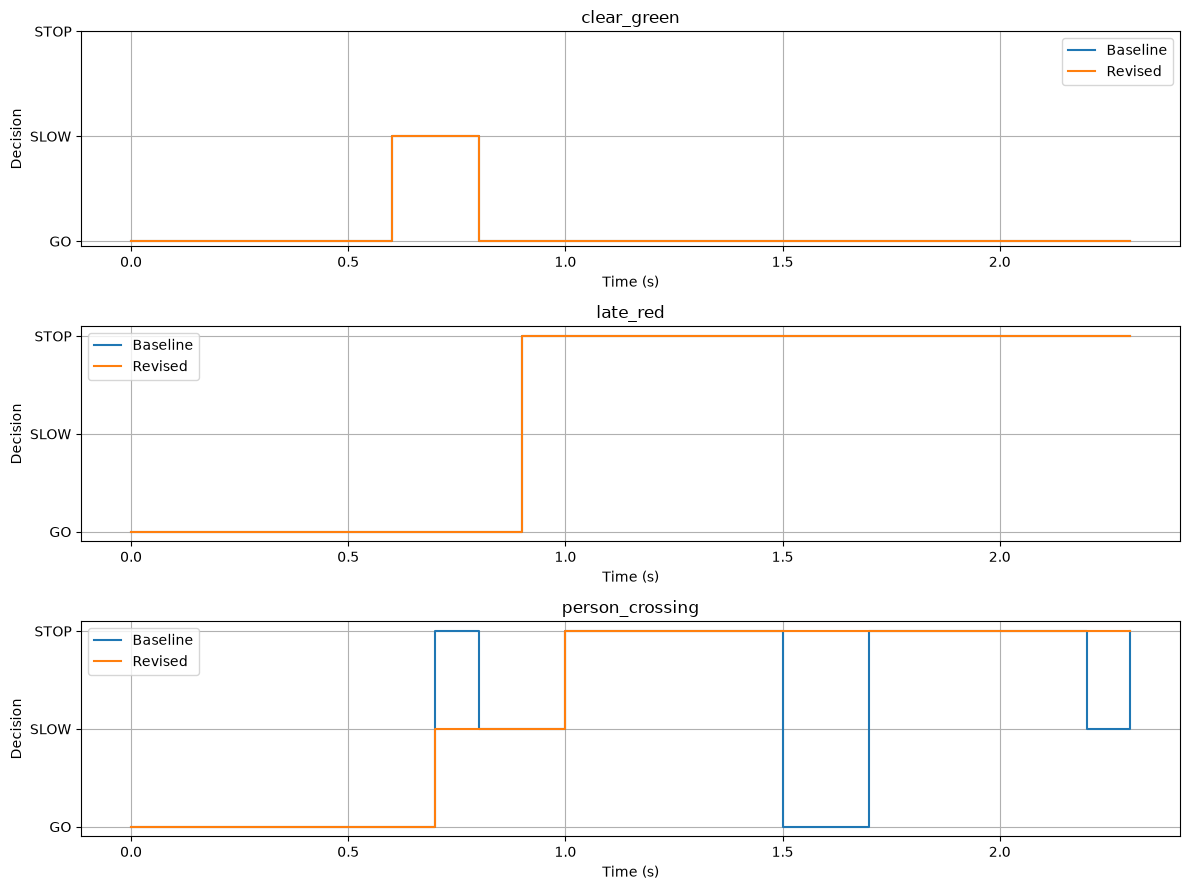

In [17]:
revised_df["revised_value"] = (
    revised_df["revised_action"]
    .map(action_value)
)

plt.figure(figsize=(12, 9))

for i, episode in enumerate(episodes):

    temp = revised_df[
        revised_df["episode"] == episode
    ]

    plt.subplot(3, 1, i + 1)

    plt.step(
        temp["time_s"],
        temp["baseline_value"],
        where="post",
        label="Baseline"
    )

    plt.step(
        temp["time_s"],
        temp["revised_value"],
        where="post",
        label="Revised"
    )

    plt.yticks(
        [0, 1, 2],
        ["GO", "SLOW", "STOP"]
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Decision")
    plt.title(episode)

    plt.grid()
    plt.legend()


plt.tight_layout()
plt.show()

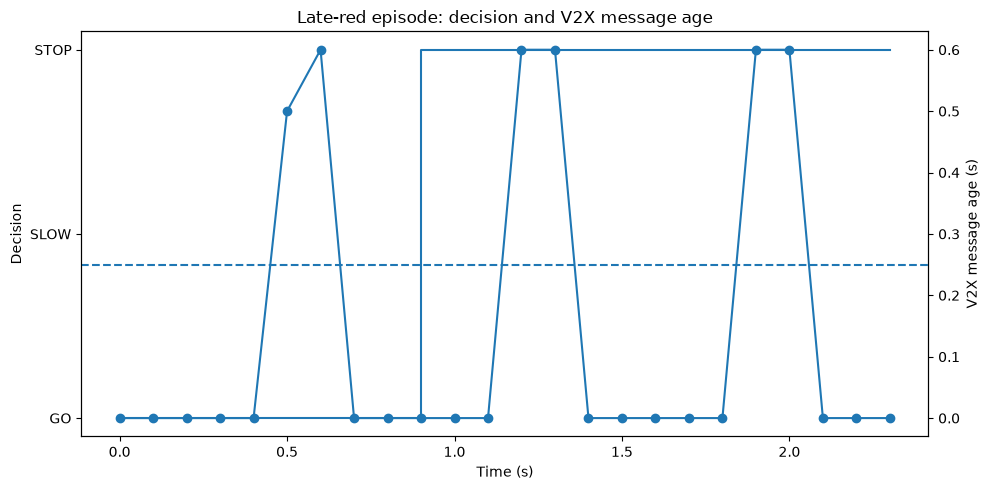

In [18]:
late = revised_df[
    revised_df["episode"] == "late_red"
]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.step(
    late["time_s"],
    late["revised_value"],
    where="post",
    label="Revised decision"
)

ax1.set_yticks(
    [0, 1, 2],
    ["GO", "SLOW", "STOP"]
)

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Decision")


ax2 = ax1.twinx()

ax2.plot(
    late["time_s"],
    late["message_age"],
    marker="o",
    label="V2X message age"
)

ax2.axhline(
    0.25,
    linestyle="--",
    label="Freshness threshold"
)

ax2.set_ylabel("V2X message age (s)")

plt.title("Late-red episode: decision and V2X message age")

fig.tight_layout()
plt.show()

### Stale V2X disagreement

In the late-red episode, some frames contain a strong red vision score while the V2X message still says green.

The message age shows that this green state was sampled earlier and should not be treated as equally current evidence.

The revised rule therefore uses V2X red only when the message is fresh and allows strong current camera evidence to override an old green message.

When evidence is weaker or contradictory, `SLOW` is preferable to assuming that an old green message means the crossing is safe.

## D. Stopping-distance check

A correct STOP decision can still be unsafe if it is issued too late.

The assignment gives:

\[
d_{stop}=v\tau+\frac{v^2}{2a}
\]

where:

- processing and actuation delay, \(\tau = 0.15\,s\)
- comfortable braking magnitude, \(a = 0.8\,m/s^2\)

I calculate this distance at the first STOP request in each episode and compare it with the remaining distance to the stop line.

In [19]:
delay = 0.15
braking = 0.8

def stopping_distance(v):
    return v * delay + (v**2) / (2 * braking)


stop_results = []

for episode in episodes:

    temp = revised_df[
        revised_df["episode"] == episode
    ]

    stops = temp[
        temp["revised_action"] == "STOP"
    ]

    if len(stops) == 0:

        stop_results.append({
            "episode": episode,
            "first_stop_frame": None,
            "speed_mps": None,
            "distance_to_line_m": None,
            "stopping_distance_m": None,
            "comfortable_stop_possible": "No STOP request"
        })

        continue

    first = stops.iloc[0]

    d_stop = stopping_distance(first["speed_mps"])

    possible = (
        first["distance_to_line_m"] >= d_stop
    )

    stop_results.append({
        "episode": episode,
        "first_stop_frame": first["frame"],
        "speed_mps": first["speed_mps"],
        "distance_to_line_m": first["distance_to_line_m"],
        "stopping_distance_m": round(d_stop, 3),
        "comfortable_stop_possible": possible
    })


stop_table = pd.DataFrame(stop_results)

stop_table

,episode,first_stop_frame,speed_mps,distance_to_line_m,stopping_distance_m,comfortable_stop_possible
0,clear_green,NaN,NaN,NaN,NaN,No STOP request
1,late_red,9.0,0.8,2.03,0.52,True
2,person_crossing,10.0,0.8,1.95,0.52,True


### Stopping-distance result

At 0.8 m/s, the approximate comfortable stopping distance is 0.52 m.

The first STOP requests in the red-light and pedestrian episodes occur while the car is still substantially farther from the stop line than this distance.

The clear-green episode does not generate a STOP request.

This indicates that the revised decisions are not only classified correctly but also occur early enough for comfortable braking in these test sequences.

## E. Evaluation against the reference decisions

The reference file is used only after the baseline and revised rules have been fixed.

I compare the predicted STOP decisions with the provided `stop_required` labels.

I measure:

- missed STOP frames: STOP was required but the system did not request STOP
- unnecessary STOP frames: the system requested STOP when STOP was not required
- response delay from the first required STOP frame to the first STOP request

In [20]:
reference = pd.read_csv(
    "data/city/crossing_reference.csv"
)

evaluation = revised_df.merge(
    reference,
    on=["episode", "frame"]
)

evaluation.head()

,episode,frame,time_s,distance_to_line_m,speed_mps,red_score,person_score,v2x_light,v2x_sample_time_s,baseline_action,baseline_reason,baseline_value,message_age,revised_action,revised_reason,revised_value,true_light,person_on_crossing,stop_required
0,clear_green,0,0.0,2.75,0.8,0.010,0.010,green,0.0,GO,no strong hazard evidence,0,0.0,GO,no strong hazard evidence,0,green,0,0
1,clear_green,1,0.1,2.67,0.8,0.010,0.113,green,0.1,GO,no strong hazard evidence,0,0.0,GO,no strong hazard evidence,0,green,0,0
2,clear_green,2,0.2,2.59,0.8,0.028,0.010,green,0.2,GO,no strong hazard evidence,0,0.0,GO,no strong hazard evidence,0,green,0,0
3,clear_green,3,0.3,2.51,0.8,0.010,0.153,green,0.3,GO,no strong hazard evidence,0,0.0,GO,no strong hazard evidence,0,green,0,0
4,clear_green,4,0.4,2.43,0.8,0.040,0.456,green,0.4,GO,no strong hazard evidence,0,0.0,GO,no strong hazard evidence,0,green,0,0


In [21]:
def evaluate_actions(df, action_column):

    missed_stop = (
        (df["stop_required"] == 1) &
        (df[action_column] != "STOP")
    ).sum()

    unnecessary_stop = (
        (df["stop_required"] == 0) &
        (df[action_column] == "STOP")
    ).sum()

    return missed_stop, unnecessary_stop


baseline_missed, baseline_unnecessary = evaluate_actions(
    evaluation,
    "baseline_action"
)

revised_missed, revised_unnecessary = evaluate_actions(
    evaluation,
    "revised_action"
)


comparison = pd.DataFrame({
    "method": ["Baseline", "Revised"],
    "missed_STOP_frames": [
        baseline_missed,
        revised_missed
    ],
    "unnecessary_STOP_frames": [
        baseline_unnecessary,
        revised_unnecessary
    ]
})

comparison

,method,missed_STOP_frames,unnecessary_STOP_frames
0,Baseline,3,1
1,Revised,0,0


In [22]:
delay_rows = []

for method, action_col in [
    ("Baseline", "baseline_action"),
    ("Revised", "revised_action")
]:

    for episode in episodes:

        temp = evaluation[
            evaluation["episode"] == episode
        ]

        required = temp[
            temp["stop_required"] == 1
        ]

        if len(required) == 0:
            continue

        first_required_time = required.iloc[0]["time_s"]

        stop_requests = temp[
            (temp[action_col] == "STOP") &
            (temp["time_s"] >= first_required_time)
        ]

        if len(stop_requests) == 0:
            response_delay = None

        else:
            first_stop_time = stop_requests.iloc[0]["time_s"]

            response_delay = (
                first_stop_time
                - first_required_time
            )


        delay_rows.append({
            "method": method,
            "episode": episode,
            "first_required_time_s": first_required_time,
            "response_delay_s": response_delay
        })


delay_table = pd.DataFrame(delay_rows)

delay_table

,method,episode,first_required_time_s,response_delay_s
0,Baseline,late_red,0.9,0.0
1,Baseline,person_crossing,1.0,0.0
2,Revised,late_red,0.9,0.0
3,Revised,person_crossing,1.0,0.0


## F. Uncertainty test

To test sensitivity to noisy perception scores, I add Gaussian noise to both vision scores.

Settings:

- random seed: 42
- trials: 20
- noise standard deviation: 0.08

Scores are clipped to the valid range [0, 1].

For every trial, the exact same perturbed evidence is supplied to both the baseline and revised rules.

In [23]:
np.random.seed(42)

trial_results = []

for trial in range(20):

    noisy = evidence.copy()

    red_noise = np.random.normal(
        0,
        0.08,
        len(noisy)
    )

    person_noise = np.random.normal(
        0,
        0.08,
        len(noisy)
    )


    noisy["red_score"] = np.clip(
        noisy["red_score"] + red_noise,
        0,
        1
    )

    noisy["person_score"] = np.clip(
        noisy["person_score"] + person_noise,
        0,
        1
    )


    # baseline on noisy data
    baseline_actions = []

    for i in range(len(noisy)):

        action, reason = baseline_decision(
            noisy.iloc[i]
        )

        baseline_actions.append(action)

    noisy["baseline_action"] = baseline_actions


    # message age needed by revised rule
    noisy["message_age"] = (
        noisy["time_s"]
        - noisy["v2x_sample_time_s"]
    )


    # revised rule
    revised_parts = []

    for episode in noisy["episode"].unique():

        temp = noisy[
            noisy["episode"] == episode
        ].copy()

        revised_part = revised_episode_decisions(
            temp
        )

        revised_parts.append(revised_part)


    noisy_revised = pd.concat(
        revised_parts,
        ignore_index=True
    )


    scored = noisy_revised.merge(
        reference,
        on=["episode", "frame"]
    )


    baseline_missed, baseline_unnecessary = evaluate_actions(
        scored,
        "baseline_action"
    )

    revised_missed, revised_unnecessary = evaluate_actions(
        scored,
        "revised_action"
    )


    trial_results.append({
        "trial": trial + 1,
        "baseline_missed": baseline_missed,
        "baseline_unnecessary": baseline_unnecessary,
        "revised_missed": revised_missed,
        "revised_unnecessary": revised_unnecessary
    })


trials_df = pd.DataFrame(trial_results)

trials_df

,trial,baseline_missed,baseline_unnecessary,revised_missed,revised_unnecessary
0,1,4,0,2,0
1,2,4,2,2,0
2,3,4,1,0,0
3,4,3,1,0,0
4,5,4,1,2,0
5,6,3,1,2,0
6,7,3,1,1,0
7,8,4,3,0,0
8,9,3,0,0,0
9,10,2,1,1,0


In [24]:
trial_summary = pd.DataFrame({
    "method": [
        "Baseline",
        "Revised"
    ],

    "mean_missed_STOP_frames": [
        trials_df["baseline_missed"].mean(),
        trials_df["revised_missed"].mean()
    ],

    "mean_unnecessary_STOP_frames": [
        trials_df["baseline_unnecessary"].mean(),
        trials_df["revised_unnecessary"].mean()
    ]
})

trial_summary = trial_summary.round(2)

trial_summary

,method,mean_missed_STOP_frames,mean_unnecessary_STOP_frames
0,Baseline,3.4,1.55
1,Revised,1.1,0.00


## G. Failure analysis

Two types of errors are especially important.

### False alarm

In the baseline, a high person score can immediately trigger STOP even when the person evidence appears relatively early and the car is still farther from the crossing.

This creates an unnecessary STOP in at least one frame.

The revised rule first uses SLOW while the car is still approaching and requests STOP only when the person evidence remains strong near the crossing.

### Dangerous delay

A more serious failure occurs when STOP is actually required but noisy or temporarily weak evidence prevents the threshold from being crossed.

The baseline treats each frame independently, so a brief score drop can cause it to miss required STOP frames.

The revised rule reduces this failure by keeping a short STOP latch after strong person evidence has triggered a STOP.

## H. Perception-to-decision flow

The running system uses only the available sensor and vehicle-state information. The reference labels are not part of the decision pipeline.

Camera image provides:
- red-light vision score
- person vision score

V2X provides:
- traffic-light state
- message timestamp

The vehicle state provides:
- current speed
- distance to the stop line

These inputs are combined by the decision rule to produce one of three outputs:

**GO, SLOW, or STOP**

A useful way to represent the flow is:

Camera evidence → Vision scores  
V2X state + timestamp → Freshness check  
Speed + distance → Stopping feasibility  
All evidence → Decision rule → GO / SLOW / STOP

The vision scores are uncertain observations rather than calibrated probabilities.

The V2X state is also treated cautiously when its timestamp indicates that the message is stale.

Speed and distance do not directly identify the hazard, but they determine whether a STOP request can still be executed comfortably.

## I. Conclusion

The baseline shows that simple thresholding of individual signals is not sufficient when different sources of evidence can be noisy, delayed, or contradictory.

The revised rule improves the decision process in three ways:

1. It checks the age of the V2X message before trusting it.
2. It uses the distance to the crossing when interpreting strong person evidence.
3. It keeps a short STOP latch so that one temporarily weak frame does not immediately cancel a previously detected hazard.

On the supplied sequences, these changes reduce both missed STOP decisions and unnecessary STOP decisions compared with the baseline.

The revised system is still intentionally simple. A stronger system would estimate whether a detected person is actually inside the vehicle's path and could maintain a more continuous belief about the traffic-light state instead of relying only on fixed thresholds.

For this assignment, the revised rule provides an interpretable way to combine uncertain camera evidence, V2X information, and vehicle state before producing a GO, SLOW, or STOP recommendation.

In [27]:
os.makedirs("outputs/q2", exist_ok=True)

comparison.to_csv(
    "outputs/q2/baseline_vs_revised.csv",
    index=False
)

stop_table.to_csv(
    "outputs/q2/stopping_distance.csv",
    index=False
)

delay_table.to_csv(
    "outputs/q2/response_delay.csv",
    index=False
)

trials_df.to_csv(
    "outputs/q2/uncertainty_trials.csv",
    index=False
)

trial_summary.to_csv(
    "outputs/q2/uncertainty_summary.csv",
    index=False
)

print("Q2 outputs saved.")

Q2 outputs saved.
